Libraries imported successfully
H0 (SI) = 2.262e-18 s^-1

Searching for CSV file...
CSV files found: ['exoplanets2.csv', 'exoplanets.csv', 'kappa0_results.csv', 'exoplanets_kappa0.csv', 'exoplanets_clean.csv']
Reading: exoplanets.csv
Raw rows read: 5000
After removing repeated headers: 5000 rows
After removing duplicates: 4521 rows
Final valid data rows: 4521
Cleaned data saved as exoplanets_clean.csv

Data preview:
         pl_name  st_rad   pl_rade  pl_orbsmax
0   Kepler-467 b   0.930   1.69000     0.16700
1      HATS-24 b   1.194  17.37395     0.02576
2   Kepler-325 b   0.982   2.94000     0.05170
3  Kepler-1521 b   0.693   2.30200     0.23476
4   Kepler-558 b   0.797   2.34000     0.17600

Total systems used: 4521

First 20 kappa0 values:
         pl_name st_rad pl_rade pl_orbsmax    kappa0
    Kepler-467 b  0.930    1.69     0.1670 2.102e-21
       HATS-24 b  1.194   17.37     0.0258 1.799e-19
    Kepler-325 b  0.982    2.94     0.0517 1.248e-20
   Kepler-1521 b  0.693    2.30    

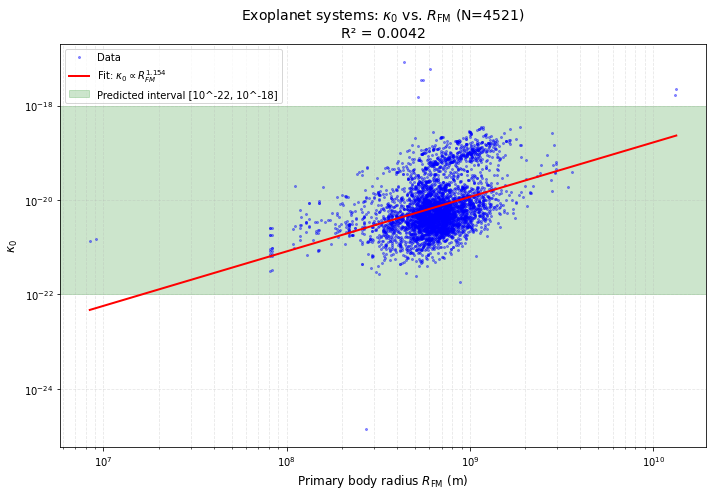


All tasks completed successfully!


In [3]:
# ============================================================
# 1. Install required packages (if not already installed)
# ============================================================
!pip install numpy pandas matplotlib -q

# ============================================================
# 2. Import libraries
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

print("Libraries imported successfully")

# ============================================================
# 3. Constants definition
# ============================================================
H0 = 69.8                         # km/s/Mpc
H0_SI = H0 * 1000 / (3.08567758e22)  # convert to s^-1
c = 3.0e8                         # m/s

R_sun = 6.957e8    # Solar radius in meters
R_earth = 6.371e6  # Earth radius in meters
AU = 1.496e11      # Astronomical unit in meters

def calc_kappa0(R_FM, R_attached, R_orbit):
    """
    Compute the dimensionless geometric constraint parameter kappa0.
    
    Parameters:
        R_FM       : physical radius of the primary body (m)
        R_attached : physical radius of the orbiting body (m)
        R_orbit    : orbital separation (m)
    
    Returns:
        kappa0 : dimensionless geometric constraint parameter
    """
    return (R_FM * R_attached * H0_SI) / (R_orbit * c)

print(f"H0 (SI) = {H0_SI:.3e} s^-1")

# ============================================================
# 4. Locate and read the uploaded CSV file
# ============================================================
print("\nSearching for CSV file...")

csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
print("CSV files found:", csv_files)

if not csv_files:
    raise FileNotFoundError("No CSV file found in the current directory")

# Prefer 'exoplanets.csv' if it exists
file_name = 'exoplanets.csv' if 'exoplanets.csv' in csv_files else csv_files[0]
print(f"Reading: {file_name}")

df_raw = pd.read_csv(file_name, encoding='utf-8', on_bad_lines='skip')
print(f"Raw rows read: {len(df_raw)}")

# Strip column names of leading/trailing spaces
df_raw.columns = df_raw.columns.str.strip()

# Attempt to auto-rename columns if standard names are missing
if 'pl_name' not in df_raw.columns:
    df_raw = pd.read_csv(file_name, header=1, encoding='utf-8', on_bad_lines='skip')
    df_raw.columns = df_raw.columns.str.strip()
    print(f"Retrying with second row as header. Rows read: {len(df_raw)}")

# Required column names
required_cols = ['pl_name', 'st_rad', 'pl_rade', 'pl_orbsmax']
missing_cols = [col for col in required_cols if col not in df_raw.columns]

if missing_cols:
    print(f"Current columns: {list(df_raw.columns)}")
    # Attempt fuzzy matching
    for col in df_raw.columns:
        col_clean = col.strip().lower()
        if 'name' in col_clean or 'pl' in col_clean:
            df_raw.rename(columns={col: 'pl_name'}, inplace=True)
        elif 'st_rad' in col_clean or 'star' in col_clean:
            df_raw.rename(columns={col: 'st_rad'}, inplace=True)
        elif 'pl_rade' in col_clean or 'planet' in col_clean:
            df_raw.rename(columns={col: 'pl_rade'}, inplace=True)
        elif 'orbsmax' in col_clean or 'orbit' in col_clean:
            df_raw.rename(columns={col: 'pl_orbsmax'}, inplace=True)
    print("Renamed columns:", list(df_raw.columns))

# Clean: remove rows where the header was accidentally repeated as data
if 'pl_name' in df_raw.columns:
    df_raw['pl_name'] = df_raw['pl_name'].astype(str)
    clean_mask = ~df_raw['pl_name'].str.contains('pl_name', case=False, na=False)
    df_clean = df_raw[clean_mask].copy()
    print(f"After removing repeated headers: {len(df_clean)} rows")
else:
    df_clean = df_raw.copy()

# Drop completely duplicate rows
df_clean = df_clean.drop_duplicates()
print(f"After removing duplicates: {len(df_clean)} rows")

# Keep only the required columns
keep_cols = ['pl_name', 'st_rad', 'pl_rade', 'pl_orbsmax']
existing_cols = [col for col in keep_cols if col in df_clean.columns]
df_final = df_clean[existing_cols].copy()

# Convert numeric columns to float; invalid entries become NaN
for col in ['st_rad', 'pl_rade', 'pl_orbsmax']:
    if col in df_final.columns:
        df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

# Drop rows with missing numeric values
df_final = df_final.dropna(subset=['st_rad', 'pl_rade', 'pl_orbsmax'])
print(f"Final valid data rows: {len(df_final)}")

if len(df_final) == 0:
    raise ValueError("No valid data remaining after cleaning. Please check the CSV format.")

# Save cleaned data
df_final.to_csv('exoplanets_clean.csv', index=False)
print("Cleaned data saved as exoplanets_clean.csv")
print("\nData preview:")
print(df_final.head())

# ============================================================
# 5. Use the full cleaned dataset
# ============================================================
df = df_final.copy()
print(f"\nTotal systems used: {len(df)}")

# ============================================================
# 6. Unit conversion and kappa0 computation
# ============================================================
df['R_FM'] = df['st_rad'] * R_sun
df['R_att'] = df['pl_rade'] * R_earth
df['R_orbit'] = df['pl_orbsmax'] * AU
df['kappa0'] = calc_kappa0(df['R_FM'], df['R_att'], df['R_orbit'])

# ============================================================
# 7. Display results (first 20 rows)
# ============================================================
print("\n" + "="*80)
print("First 20 kappa0 values:")
print("="*80)

display_cols = ['pl_name', 'st_rad', 'pl_rade', 'pl_orbsmax', 'kappa0']
print(df[display_cols].head(20).to_string(index=False, 
                                          formatters={
                                              'st_rad': '{:.3f}'.format,
                                              'pl_rade': '{:.2f}'.format,
                                              'pl_orbsmax': '{:.4f}'.format,
                                              'kappa0': '{:.3e}'.format
                                          }))

# ============================================================
# 8. Save processed data
# ============================================================
df.to_csv('kappa0_results.csv', index=False)
print("\nProcessed data saved as kappa0_results.csv")

# ============================================================
# 9. Summary statistics
# ============================================================
print("\n" + "="*80)
print("Summary Statistics:")
print("="*80)
print(f"kappa0 min:   {df['kappa0'].min():.3e}")
print(f"kappa0 max:   {df['kappa0'].max():.3e}")
print(f"kappa0 median:{df['kappa0'].median():.3e}")
print(f"kappa0 mean:  {df['kappa0'].mean():.3e}")
print(f"kappa0 std:   {df['kappa0'].std():.3e}")

# ============================================================
# 10. Order-of-magnitude interval check
#     kappa0 should be within [10^-22, 10^-18]
# ============================================================
lower_order = -22
upper_order = -18

df['log10_kappa0'] = np.log10(df['kappa0'])
orders = df['log10_kappa0'].apply(lambda x: np.floor(x))

within_range = (orders >= lower_order) & (orders <= upper_order)
count_in_range = within_range.sum()
total = len(df)

print(f"\nOrder-of-magnitude interval: [10^{lower_order}, 10^{upper_order}]")
print(f"Systems within interval: {count_in_range} / {total} ({100*count_in_range/total:.1f}%)")

# ============================================================
# 11. Outlier detection: systems outside the order-of-magnitude interval
# ============================================================
out_of_range = df[~within_range].copy()
if len(out_of_range) > 0:
    print("\n" + "="*80)
    print("⚠️ Outliers (orders of magnitude outside the predicted interval):")
    print("="*80)
    
    out_of_range_sorted = out_of_range.sort_values('kappa0')
    
    print("\n[Below lower bound 10^-22]:")
    below_lower = out_of_range_sorted[out_of_range_sorted['log10_kappa0'] < lower_order]
    if len(below_lower) > 0:
        print(below_lower[['pl_name', 'kappa0']].to_string(index=False, 
                                                           formatters={'kappa0': '{:.3e}'.format}))
        print(f"\nTotal: {len(below_lower)}")
    else:
        print("  None")
    
    print("\n[Above upper bound 10^-18]:")
    above_upper = out_of_range_sorted[out_of_range_sorted['log10_kappa0'] > upper_order]
    if len(above_upper) > 0:
        print(above_upper[['pl_name', 'kappa0']].to_string(index=False, 
                                                           formatters={'kappa0': '{:.3e}'.format}))
        print(f"\nTotal: {len(above_upper)}")
    else:
        print("  None")
else:
    print("\n✅ All systems fall within the interval!")

# ============================================================
# 12. Power-law fitting: log10(kappa0) = a * log10(R_FM) + b
# ============================================================
logR = np.log10(df['R_FM'])
logk = np.log10(df['kappa0'])
a, b = np.polyfit(logR, logk, 1)

k_fit = 10**(a * logR + b)
ss_res = np.sum((df['kappa0'] - k_fit)**2)
ss_tot = np.sum((df['kappa0'] - np.mean(df['kappa0']))**2)
r2 = 1 - (ss_res / ss_tot)

print("\n" + "="*80)
print("Power-Law Fit Results:")
print("="*80)
print(f"log10(kappa0) = {a:.4f} * log10(R_FM) + {b:.4f}")
print(f"i.e., kappa0 ∝ R_FM^{a:.4f}")
print(f"R² = {r2:.4f}")

# ============================================================
# 13. Plot: log-log scale with the predicted interval
# ============================================================
plt.figure(figsize=(10, 7))

# Scatter plot
plt.loglog(df['R_FM'], df['kappa0'], 'o', color='blue', 
           markersize=2, alpha=0.4, label='Data')

# Power-law fit line
R_fit = np.logspace(np.log10(df['R_FM'].min()), np.log10(df['R_FM'].max()), 100)
k_fit_line = 10**(a * np.log10(R_fit) + b)
plt.loglog(R_fit, k_fit_line, 'r-', linewidth=2, 
           label='Fit: $\\kappa_0 \\propto R_{FM}^{' + f'{a:.3f}' + '}$')

# Predicted interval
plt.axhspan(1e-22, 1e-18, alpha=0.2, color='green', 
            label='Predicted interval [10^-22, 10^-18]')

plt.xlabel('Primary body radius $R_{\\mathrm{FM}}$ (m)', fontsize=12)
plt.ylabel('$\\kappa_0$', fontsize=12)
plt.title('Exoplanet systems: $\\kappa_0$ vs. $R_{\\mathrm{FM}}$ (N=' + str(len(df)) + ')\n' + 'R² = ' + str(round(r2, 4)), fontsize=14)

plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAll tasks completed successfully!")

In [22]:
!pip install astroquery pyvo --upgrade --user

Looking in links: /usr/share/pip-wheels


In [19]:
# 创建一个空的 exoplanets.csv 文件
with open('exoplanets.csv', 'w', encoding='utf-8') as f:
    f.write('pl_name,st_rad,pl_rade,pl_orbsmax\n')
print("✅ 文件 exoplanets.csv 已创建，请双击编辑并粘贴数据")

✅ 文件 exoplanets.csv 已创建，请双击编辑并粘贴数据
